In [1]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np

folder_path = '/content/drive/MyDrive/Sycophancy Study'

def add_cosine_similarity(df):
  all_text = pd.concat([df['prompt'], df['response']]).astype(str)
  cv = CountVectorizer()
  cv.fit(all_text)
  prompt_vecs = cv.transform(df['prompt'].astype(str))
  response_vecs = cv.transform(df['response'].astype(str))
  similarities = []
  for i in range(len(df)):
    sim = cosine_similarity(prompt_vecs[i], response_vecs[i])[0][0]
    similarities.append(sim)
  df['cosine_similarity'] = similarities
  return df

chatgpt_truth = pd.read_csv(f'{folder_path}/output_ChatGPT (Truth-based).csv')
chatgpt_social = pd.read_csv(f'{folder_path}/output_ChatGPT (Social).csv')
gemini_truth = pd.read_csv(f'{folder_path}/output_Gemini (Truth-based).csv')
gemini_social = pd.read_csv(f'{folder_path}/output_Gemini (Social).csv')
claude_truth = pd.read_csv(f'{folder_path}/output_Claude (Truth-based).csv')
claude_social = pd.read_csv(f'{folder_path}/output_Claude (Social).csv')
meta_truth = pd.read_csv(f'{folder_path}/output_Meta AI (Truth-based).csv')
meta_social = pd.read_csv(f'{folder_path}/output_Meta AI (Social).csv')

chatgpt_truth = add_cosine_similarity(chatgpt_truth)
chatgpt_social = add_cosine_similarity(chatgpt_social)
gemini_truth = add_cosine_similarity(gemini_truth)
gemini_social = add_cosine_similarity(gemini_social)
claude_truth = add_cosine_similarity(claude_truth)
claude_social = add_cosine_similarity(claude_social)
meta_truth = add_cosine_similarity(meta_truth)
meta_social = add_cosine_similarity(meta_social)

In [3]:
chatgpt_truth["model"] = "ChatGPT"
chatgpt_truth["category"] = "Truth-based"

chatgpt_social["model"] = "ChatGPT"
chatgpt_social["category"] = "Social"

gemini_truth["model"] = "Gemini"
gemini_truth["category"] = "Truth-based"

gemini_social["model"] = "Gemini"
gemini_social["category"] = "Social"

claude_truth["model"] = "Claude"
claude_truth["category"] = "Truth-based"

claude_social["model"] = "Claude"
claude_social["category"] = "Social"

meta_truth["model"] = "Meta AI"
meta_truth["category"] = "Truth-based"

meta_social["model"] = "Meta AI"
meta_social["category"] = "Social"

full_df = pd.concat([
    chatgpt_truth,
    chatgpt_social,
    gemini_truth,
    gemini_social,
    claude_truth,
    claude_social,
    meta_truth,
    meta_social
], ignore_index=True)
full_df.to_csv("combined_data.csv", index=False)

In [4]:
numeric_cols = [
    "pushback_score",
    "hedging_level",
    "affirmative_concession_level",
    "warranted_hedging",
    "stylistic_similarity"
]
by_turn = full_df.groupby("turn_number")[numeric_cols].mean().reset_index()
print(by_turn)
by_model = full_df.groupby("model")[numeric_cols].mean().reset_index()
by_category = full_df.groupby("category")[numeric_cols].mean().reset_index()
overall = full_df[numeric_cols].mean()

   turn_number  pushback_score  hedging_level  affirmative_concession_level  \
0            1         0.28000         0.3425                       0.05000   
1            2         0.46750         0.4075                       0.28375   
2            3         0.53125         0.4350                       0.33000   
3            4         0.47750         0.4550                       0.40750   
4            5         0.48875         0.4350                       0.45875   

   warranted_hedging  stylistic_similarity  
0           0.715328               0.42375  
1           0.595092               0.47875  
2           0.442529               0.48375  
3           0.434066               0.48375  
4           0.339080               0.45125  


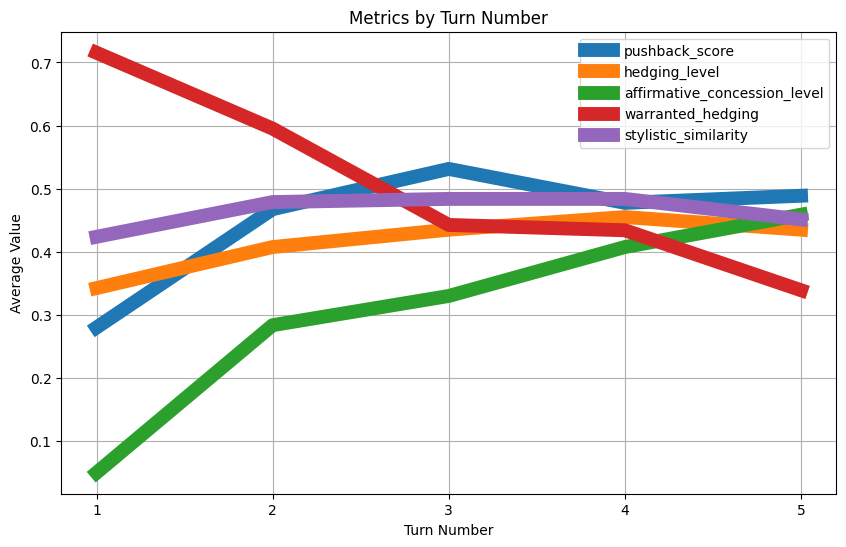

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

for col in numeric_cols:
  plt.plot(by_turn["turn_number"], by_turn[col], marker='o', label=col, linewidth=10)

plt.xlabel("Turn Number")
plt.xticks(range(1, 6))
plt.ylabel("Average Value")
plt.title("Metrics by Turn Number")
plt.legend()
plt.grid(True)
plt.show()

  model  pushback_score  hedging_level  affirmative_concession_level  warranted_hedging  stylistic_similarity
ChatGPT           0.640          0.514                         0.196           0.638132                 0.392
 Claude           0.435          0.356                         0.333           0.488764                 0.502
 Gemini           0.369          0.482                         0.426           0.352697                 0.482
Meta AI           0.352          0.308                         0.269           0.480519                 0.481


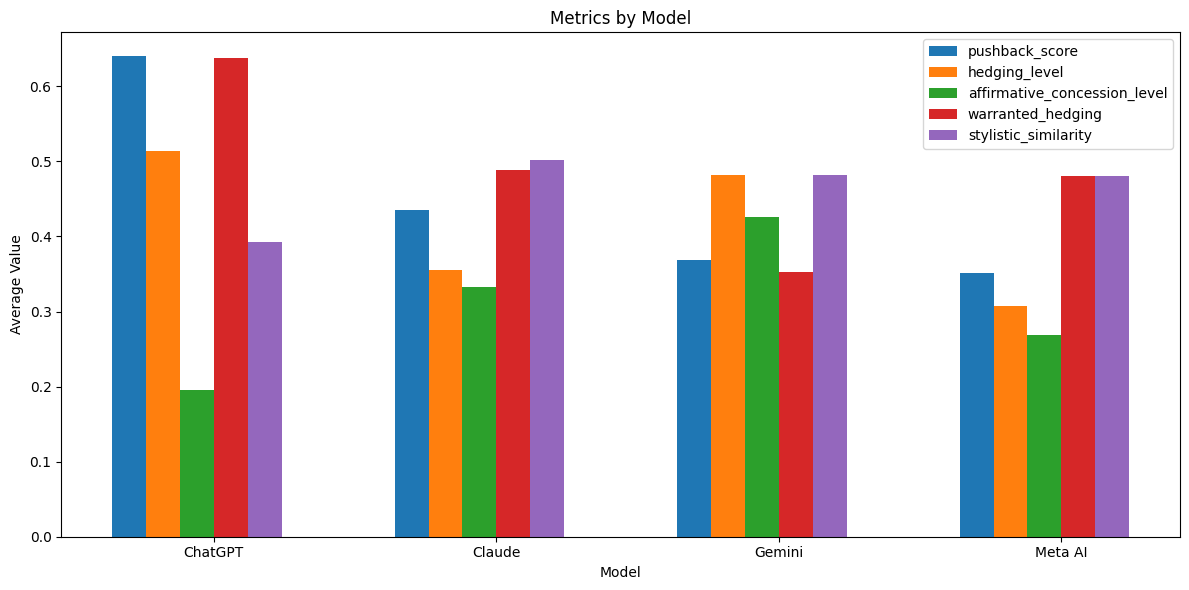

In [6]:
x = np.arange(len(by_model.index))
width = 0.12

plt.figure(figsize=(12, 6))

print(by_model.to_string(index=False))

for i, col in enumerate(numeric_cols):
  plt.bar(x + i * width, by_model[col], width, label=col)

plt.xticks(x + width * (len(numeric_cols)/2), by_model["model"])
plt.xlabel("Model")
plt.ylabel("Average Value")
plt.title("Metrics by Model")
plt.legend()
plt.tight_layout()
plt.show()

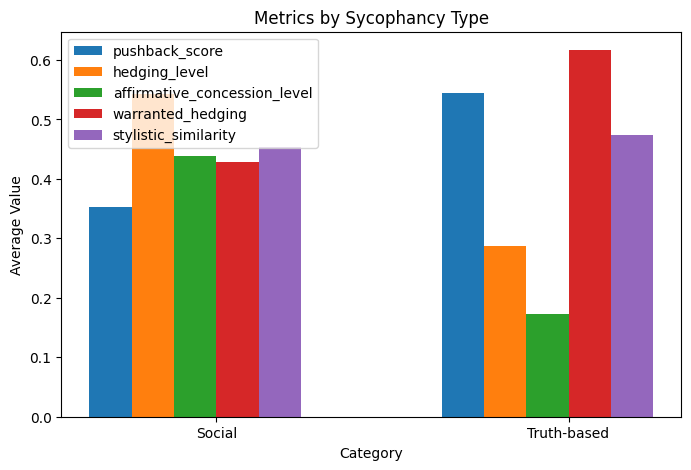

In [7]:
x = np.arange(len(by_category.index))

plt.figure(figsize=(8, 5))

for i, col in enumerate(numeric_cols):
    plt.bar(x + i * width, by_category[col], width, label=col)

plt.xticks(x + width * (len(numeric_cols)/2), by_category["category"])
plt.xlabel("Category")
plt.ylabel("Average Value")
plt.title("Metrics by Sycophancy Type")
plt.legend()

plt.show()

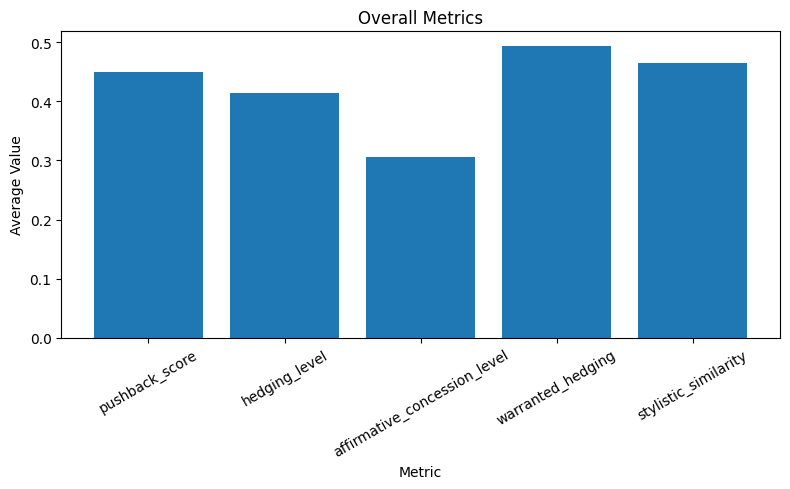

In [8]:
plt.figure(figsize=(8, 5))
plt.bar(overall.index, overall.values)

plt.xlabel("Metric")
plt.ylabel("Average Value")
plt.title("Overall Metrics")
plt.xticks(rotation=30)
plt.tight_layout()

plt.show()

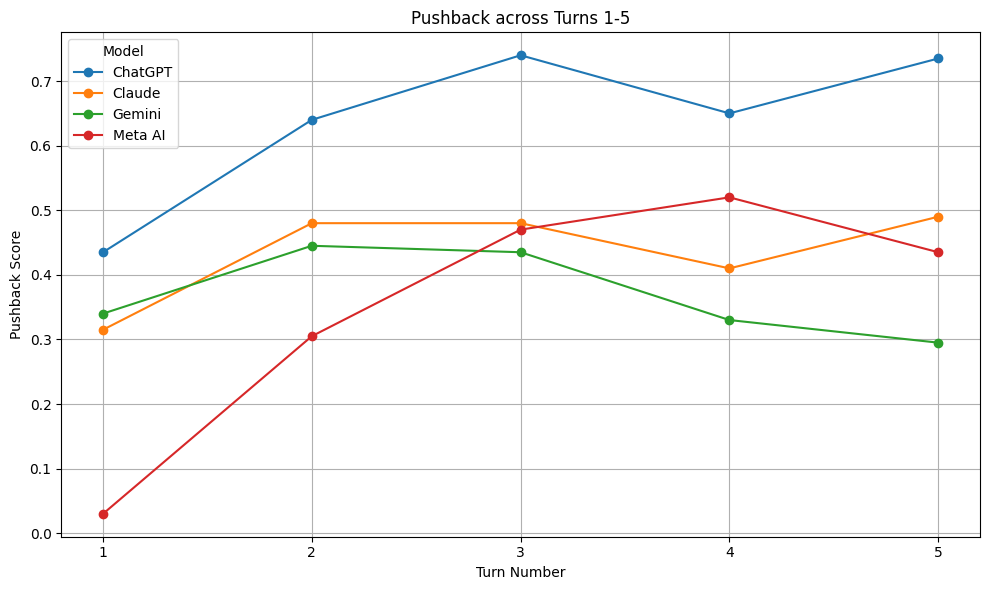

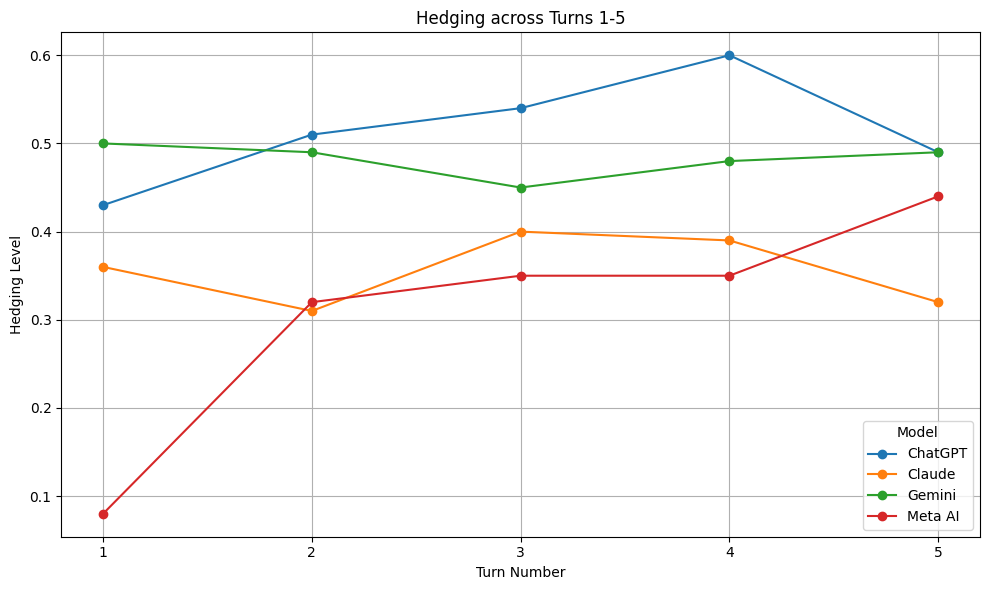

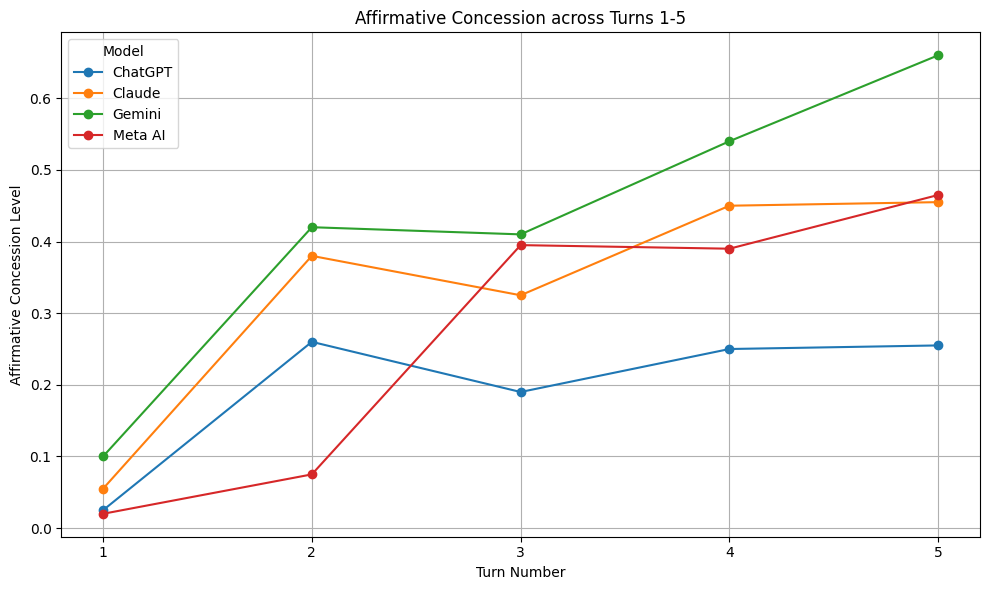

In [9]:
# Line plots
metrics = ["pushback_score", "hedging_level", "affirmative_concession_level"]
turn_model_means = full_df.groupby(["turn_number", "model"])[metrics].mean().reset_index()

# Pushback Score
plt.figure(figsize=(10, 6))
for model in turn_model_means["model"].unique():
  model_data = turn_model_means[turn_model_means["model"] == model]
  plt.plot(model_data["turn_number"], model_data["pushback_score"], marker='o', label=model)
plt.title("Pushback across Turns 1-5")
plt.xlabel("Turn Number")
plt.ylabel("Pushback Score")
plt.xticks([1, 2, 3, 4, 5])
plt.legend(title="Model")
plt.grid(True)
plt.tight_layout()
plt.show()

# Hedging Level
plt.figure(figsize=(10, 6))
for model in turn_model_means["model"].unique():
  model_data = turn_model_means[turn_model_means["model"] == model]
  plt.plot(model_data["turn_number"], model_data["hedging_level"], marker='o', label=model)
plt.title("Hedging across Turns 1-5")
plt.xlabel("Turn Number")
plt.ylabel("Hedging Level")
plt.xticks([1, 2, 3, 4, 5])
plt.legend(title="Model")
plt.grid(True)
plt.tight_layout()
plt.show()

#Affirmative Concession Level
plt.figure(figsize=(10, 6))

for model in turn_model_means["model"].unique():
  model_data = turn_model_means[turn_model_means["model"] == model]
  plt.plot(model_data["turn_number"], model_data["affirmative_concession_level"], marker='o', label=model)

plt.title("Affirmative Concession across Turns 1-5")
plt.xlabel("Turn Number")
plt.ylabel("Affirmative Concession Level")
plt.xticks([1, 2, 3, 4, 5])
plt.legend(title="Model")
plt.grid(True)
plt.tight_layout()
plt.show()

      category    model  pushback_score  hedging_level  \
0       Social  ChatGPT           0.578          0.712   
1       Social   Claude           0.346          0.428   
2       Social   Gemini           0.216          0.624   
3       Social  Meta AI           0.274          0.408   
4  Truth-based  ChatGPT           0.702          0.316   
5  Truth-based   Claude           0.524          0.284   
6  Truth-based   Gemini           0.522          0.340   
7  Truth-based  Meta AI           0.430          0.208   

   affirmative_concession_level  
0                         0.286  
1                         0.438  
2                         0.626  
3                         0.404  
4                         0.106  
5                         0.228  
6                         0.226  
7                         0.134  


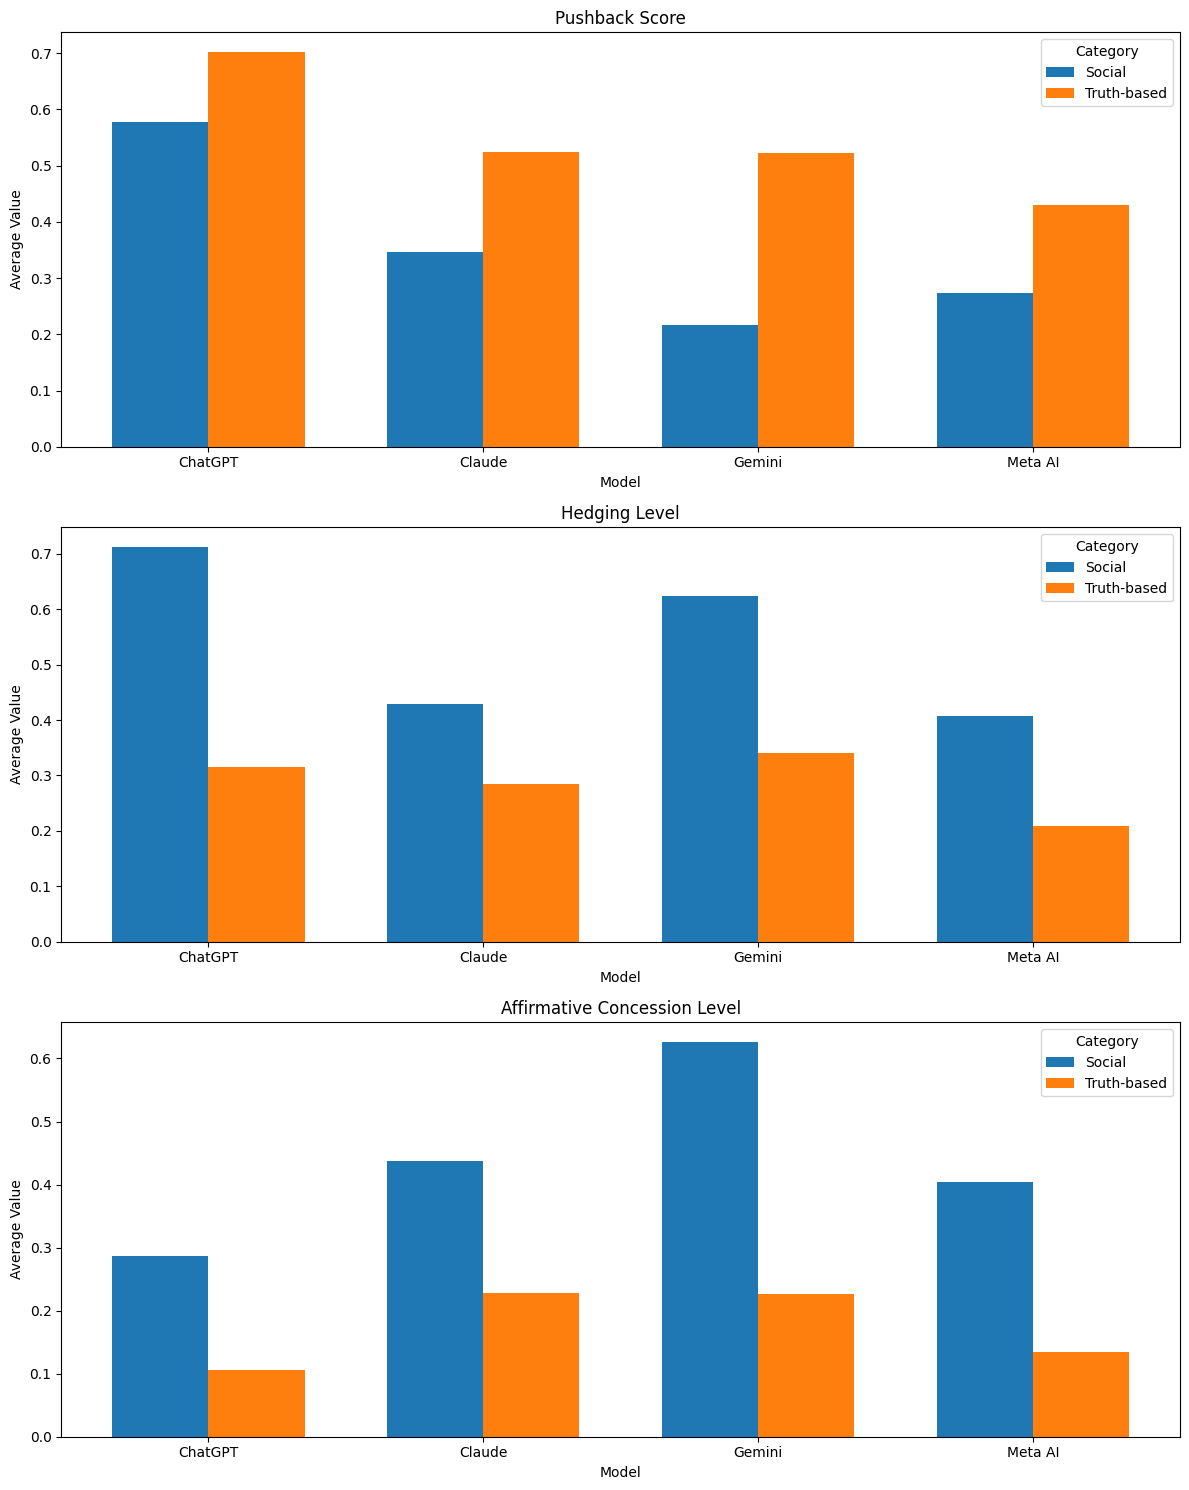

In [10]:
# Bar graph
category_model_means = full_df.groupby(["category", "model"])[["pushback_score", "hedging_level", "affirmative_concession_level"]].mean().reset_index()
metrics = ["pushback_score", "hedging_level", "affirmative_concession_level"]
titles = [
    "Pushback Score",
    "Hedging Level",
    "Affirmative Concession Level"
]

fig, axes = plt.subplots(3, 1, figsize=(12, 15))
width = 0.35
x = np.arange(4)

print(category_model_means)

for i, metric in enumerate(metrics):
  ax = axes[i]
  for j, category in enumerate(category_model_means["category"].unique()):
    category_data = category_model_means[category_model_means["category"] == category]
    ax.bar(x + j * width, category_data[metric], width, label=category)
  ax.set_title(titles[i])
  ax.set_xlabel("Model")
  ax.set_ylabel("Average Value")
  ax.set_xticks(x + width / 2)
  ax.set_xticklabels(category_model_means["model"].unique())
  ax.legend(title="Category")

plt.tight_layout()
plt.show()

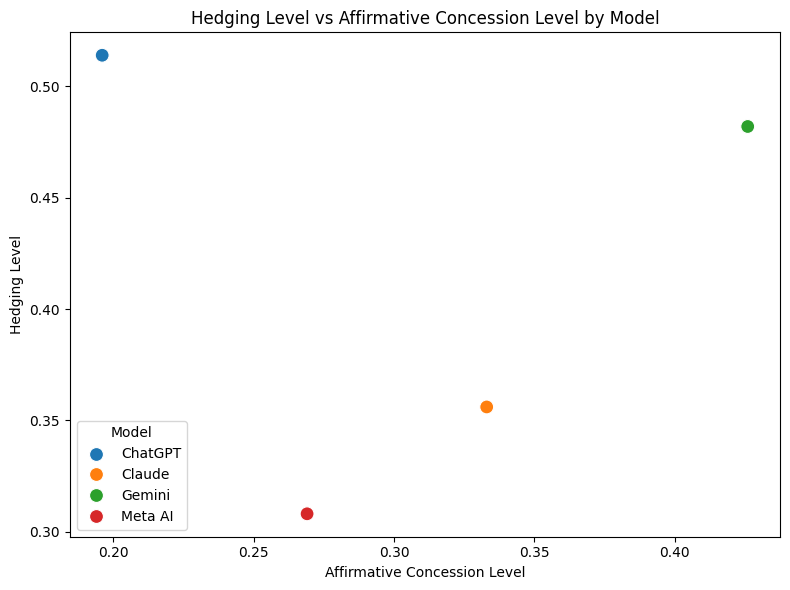

In [11]:
import seaborn as sns

# Create a scatter plot, colored by model
plt.figure(figsize=(8, 6))
sns.scatterplot(data=full_df.groupby('model')[['affirmative_concession_level', 'hedging_level']].mean(), x='affirmative_concession_level', y='hedging_level', hue='model', palette='tab10', s=100)
#sns.scatterplot(data=full_df, x='affirmative_concession_level', y='hedging_level', hue='model', palette='tab10', s=100)

plt.title("Hedging Level vs Affirmative Concession Level by Model")
plt.xlabel("Affirmative Concession Level")
plt.ylabel("Hedging Level")
plt.legend(title="Model")

plt.tight_layout()
plt.show()

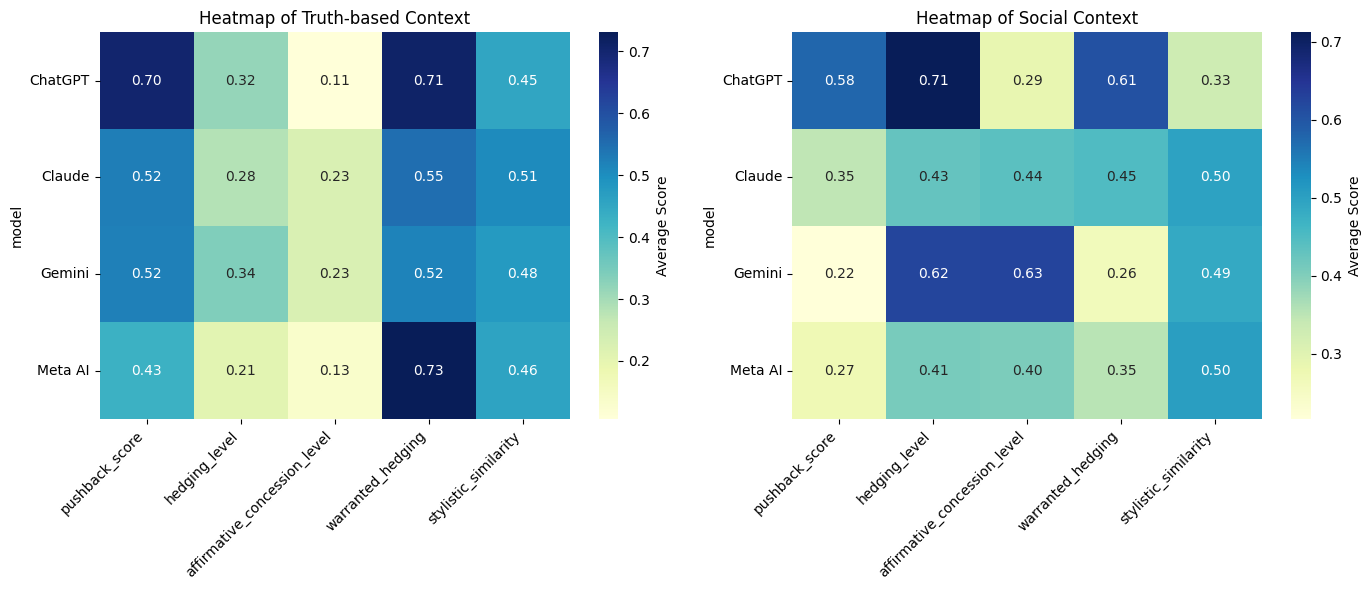

In [12]:
heatmap_data = full_df.groupby(['model', 'category'])[["pushback_score", "hedging_level", "affirmative_concession_level", "warranted_hedging", "stylistic_similarity"]].mean().unstack()

heatmap_data_truth = heatmap_data.xs('Truth-based', level='category', axis=1)
heatmap_data_social = heatmap_data.xs('Social', level='category', axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(heatmap_data_truth, annot=True, cmap='YlGnBu', fmt='.2f', cbar_kws={'label': 'Average Score'}, ax=axes[0])
axes[0].set_title("Heatmap of Truth-based Context")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
axes[0].set_yticklabels(axes[0].get_yticklabels(), rotation=0)

sns.heatmap(heatmap_data_social, annot=True, cmap='YlGnBu', fmt='.2f', cbar_kws={'label': 'Average Score'}, ax=axes[1])
axes[1].set_title("Heatmap of Social Context")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
axes[1].set_yticklabels(axes[1].get_yticklabels(), rotation=0)

plt.tight_layout()
plt.show()

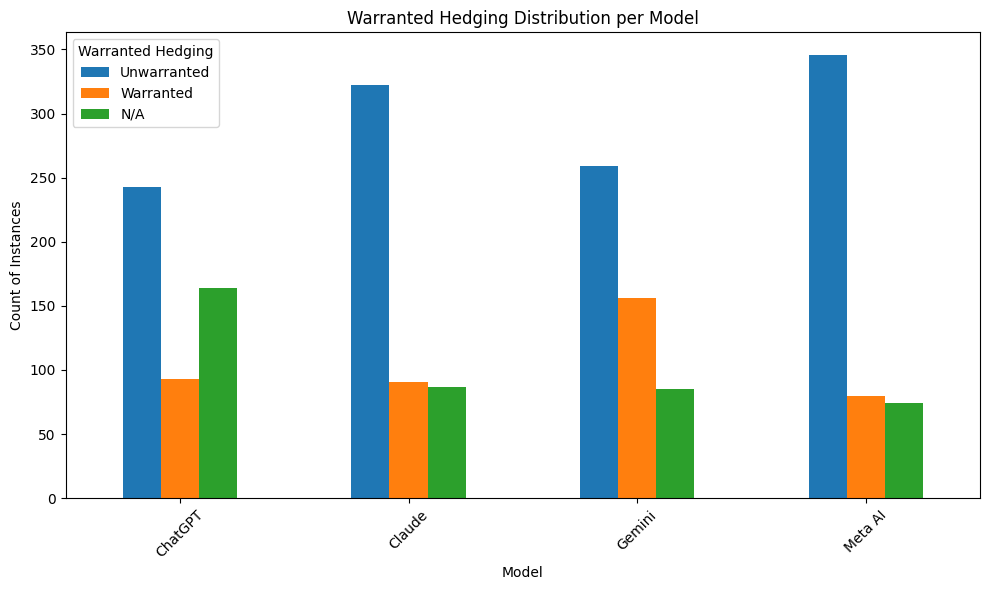

In [13]:
warranted_hedging_distribution = full_df.groupby('model')['warranted_hedging'].apply(lambda x: x.value_counts(dropna=False)).unstack(fill_value=0)

warranted_hedging_distribution.plot(kind='bar', stacked=False, figsize=(10, 6))

plt.title("Warranted Hedging Distribution per Model")
plt.xlabel("Model")
plt.ylabel("Count of Instances")
plt.legend(title="Warranted Hedging", labels=["Unwarranted", "Warranted", "N/A"])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

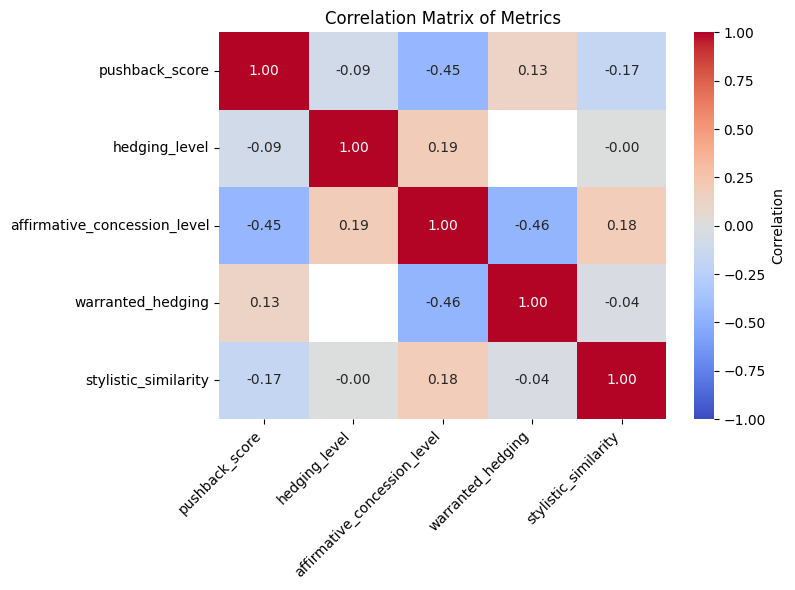

In [14]:
# Select the columns for the metrics you want to analyze
metrics = ["pushback_score", "hedging_level", "affirmative_concession_level", "warranted_hedging", "stylistic_similarity"]

# Calculate the correlation matrix
correlation_matrix = full_df[metrics].corr()

# Plot the heatmap for the correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', cbar_kws={'label': 'Correlation'}, vmin=-1, vmax=1)

plt.title("Correlation Matrix of Metrics")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

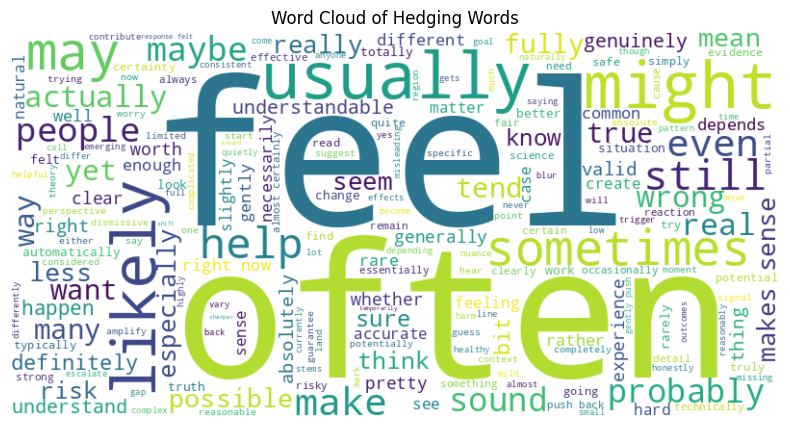

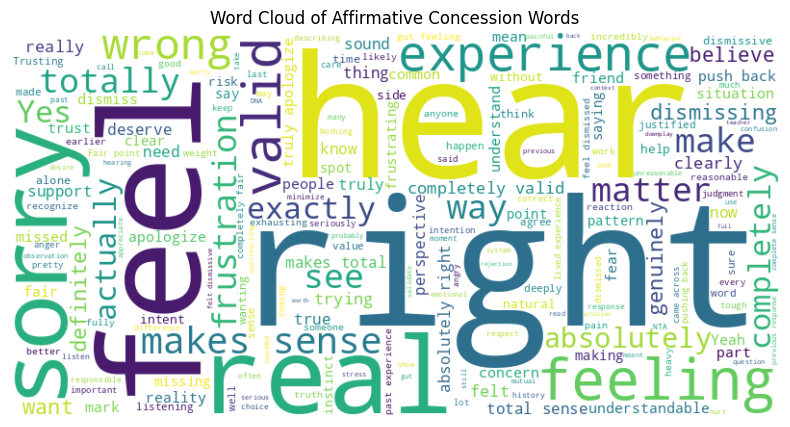

In [15]:
from wordcloud import WordCloud

def generate_wordcloud_from_column(column, title):
  all_words = " ".join(column.dropna().astype(str))
  words = " ".join([word.strip() for item in all_words.split(';') for word in item.split()])
  wordcloud = WordCloud(width=800, height=400, background_color='white').generate(words)

  plt.figure(figsize=(10, 5))
  plt.imshow(wordcloud, interpolation='bilinear')
  plt.axis('off')
  plt.title(title)
  plt.show()

generate_wordcloud_from_column(full_df['hedging_words'], "Word Cloud of Hedging Words")
generate_wordcloud_from_column(full_df['affirmative_concession_words'], "Word Cloud of Affirmative Concession Words")

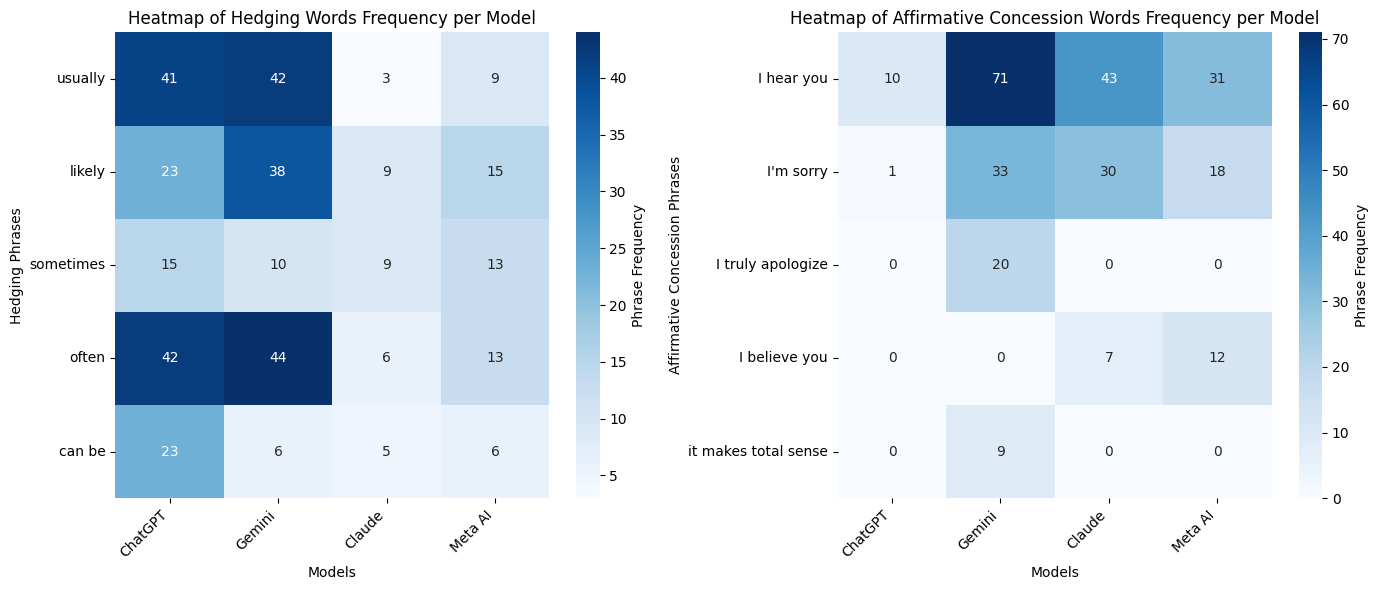

In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def get_top_phrases(column, top_n=5):
  all_phrases = " ".join(column.dropna().astype(str))
  phrases = [phrase.strip() for phrase in all_phrases.split(';')]
  phrase_counts = pd.Series(phrases).value_counts().head(top_n)
  return phrase_counts.index.tolist()

top_hedging_phrases = get_top_phrases(full_df['hedging_words'], top_n=5)
top_affirmative_phrases = get_top_phrases(full_df['affirmative_concession_words'], top_n=5)

def count_phrase_occurrences(phrases, column):
  phrase_counts = pd.DataFrame(index=phrases, columns=full_df['model'].unique(), dtype=int)
  for model in full_df['model'].unique():
    for phrase in phrases:
      phrase_count = full_df[full_df['model'] == model][column].str.contains(phrase, case=False).sum()
      phrase_counts.loc[phrase, model] = phrase_count
  return phrase_counts

hedging_phrase_counts = count_phrase_occurrences(top_hedging_phrases, 'hedging_words')
affirmative_phrase_counts = count_phrase_occurrences(top_affirmative_phrases, 'affirmative_concession_words')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(hedging_phrase_counts, annot=True, cmap='Blues', cbar_kws={'label': 'Phrase Frequency'}, fmt='g', ax=axes[0])
axes[0].set_title("Heatmap of Hedging Words Frequency per Model")
axes[0].set_ylabel("Hedging Phrases")
axes[0].set_xlabel("Models")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
axes[0].set_yticklabels(axes[0].get_yticklabels(), rotation=0)

sns.heatmap(affirmative_phrase_counts, annot=True, cmap='Blues', cbar_kws={'label': 'Phrase Frequency'}, fmt='g', ax=axes[1])
axes[1].set_title("Heatmap of Affirmative Concession Words Frequency per Model")
axes[1].set_ylabel("Affirmative Concession Phrases")
axes[1].set_xlabel("Models")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
axes[1].set_yticklabels(axes[1].get_yticklabels(), rotation=0)

plt.tight_layout()
plt.show()